In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn  as sns


#### Variables de dataset loan_prediction_dataset
- age (integer): Age of the applicant in years, ranging from 20 to 70.
- income (float): Annual income of the applicant in dollars, ranging from approximately 4,000 to 100,000, with a right.
- credit_score (integer): Credit score of the applicant, ranging from 300 to 850.
- dependents (integer): Number of dependents the applicant has, ranging from 0 to 4.
- home_owner (binary, 0/1): Indicates if the applicant owns a home (1 for yes, 0 for no).
- loan_approved (binary, 0/1): Target variable (1 for approved, 0 for denied), indicating the loan approval decision.

In [15]:
df = pd.read_csv("loan_prediction_dataset.csv")
print(df)

     age     income  credit_score  dependents  home_owner  loan_approved
0     54  100000.00           334           0           1              1
1     67   85233.42           593           2           1              1
2     29   16737.15           502           0           0              1
3     42   69332.50           367           3           0              0
4     58   28211.14           430           0           1              1
..   ...        ...           ...         ...         ...            ...
995   68   18279.98           379           3           0              0
996   41    8244.06           653           4           1              1
997   39   16194.69           460           2           1              1
998   52   38739.91           726           2           1              1
999   24   11278.55           702           0           0              1

[1000 rows x 6 columns]


In [3]:
df.dtypes

age                int64
income           float64
credit_score       int64
dependents         int64
home_owner         int64
loan_approved      int64
dtype: object

In [4]:
df.isnull().values.any()

np.False_

In [5]:
pd.crosstab(df["loan_approved"],df["dependents"])


dependents,0,1,2,3,4
loan_approved,,,,,
0,8,19,45,61,85
1,191,174,152,143,122


In [6]:
pd.crosstab(df["home_owner"], df["loan_approved"])


loan_approved,0,1
home_owner,,
0,140,366
1,78,416


<Axes: xlabel='loan_approved', ylabel='credit_score'>

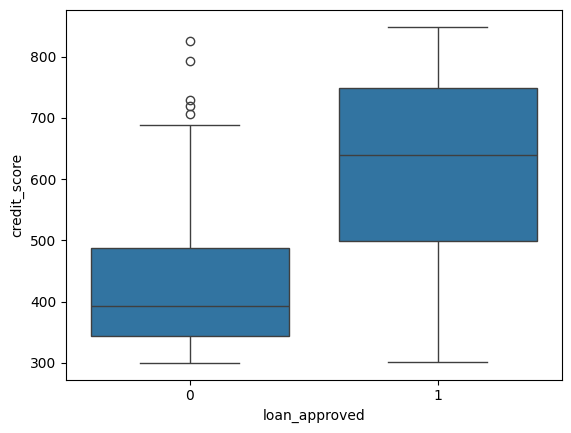

In [7]:
sns.boxplot(x="loan_approved" , y="credit_score", data=df)


<Axes: xlabel='loan_approved', ylabel='income'>

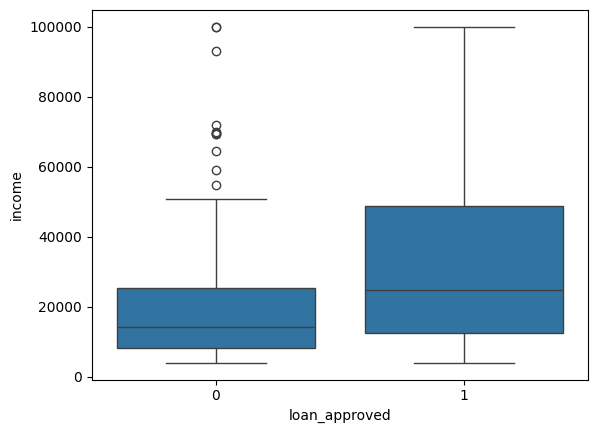

In [8]:
sns.boxplot(x="loan_approved" , y="income", data=df)


<Axes: xlabel='dependents', ylabel='income'>

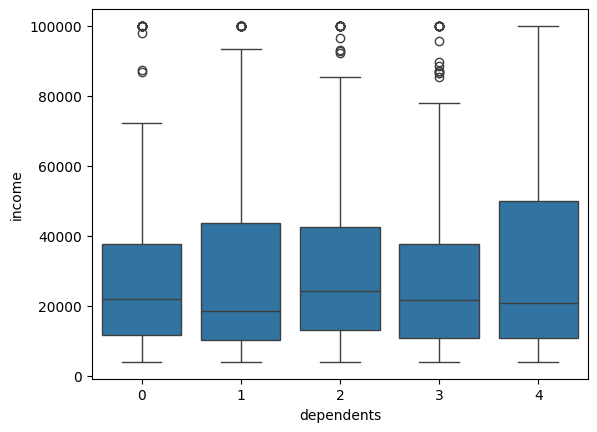

In [9]:
sns.boxplot(x="dependents" , y="income", data=df)


<Axes: xlabel='age', ylabel='income'>

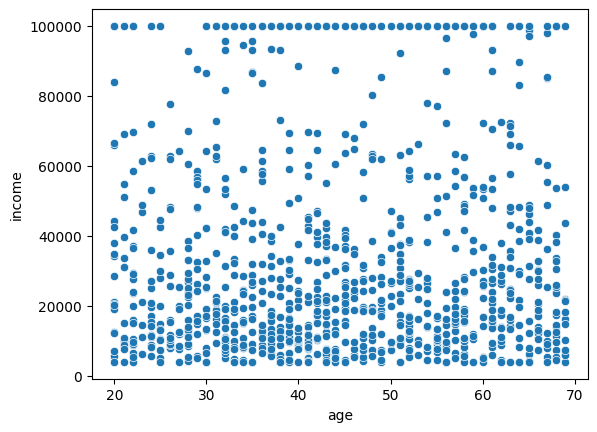

In [10]:
sns.scatterplot(x="age", y="income", data=df)

<Axes: xlabel='home_owner', ylabel='income'>

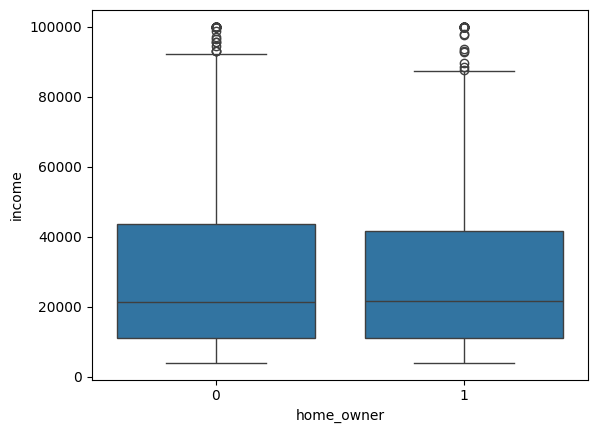

In [11]:
sns.boxplot(x="home_owner" , y="income", data=df)


<Axes: xlabel='loan_approved', ylabel='count'>

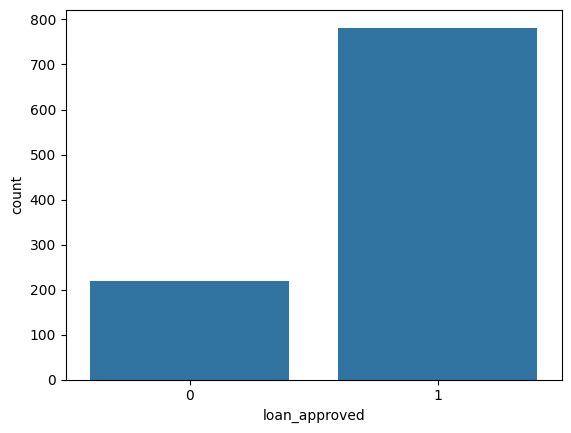

In [12]:
sns.countplot(x="loan_approved", data=df)

In [13]:
X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]

x_train, x_test,y_train, y_test = train_test_split(
    X,
    y, 
    train_size=0.8,
    random_state=42,
    stratify=y)


In [16]:
arbol = RandomForestClassifier(n_estimators=100, 
                               max_depth=10,
                               class_weight="balanced",
                               random_state=25)

In [19]:
arbol.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
arbol.feature_importances_

array([0.10816296, 0.19003977, 0.4969714 , 0.17488206, 0.02994381])

In [30]:
y_prediccion = arbol.predict(x_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_score(y_test, y_prediccion)

0.835

In [35]:
print(classification_report(y_test, y_prediccion))

              precision    recall  f1-score   support

           0       0.64      0.57      0.60        44
           1       0.88      0.91      0.90       156

    accuracy                           0.83       200
   macro avg       0.76      0.74      0.75       200
weighted avg       0.83      0.83      0.83       200



In [38]:
confusion_matrix(y_test, y_prediccion)

array([[ 25,  19],
       [ 14, 142]])

El modelo hasta ahora le va bastnate bien con la prediccion de a quien SÍ se le aprobó el credito, pero falla mucho para rechazar a la gente ue hay que rechazar. Se probará un arbol con distinto class_weigth

In [51]:
arbol_2 = RandomForestClassifier(n_estimators=100, 
                               max_depth=10,
                                random_state=25,
                                class_weight="balanced_subsample")
arbol_3 = RandomForestClassifier(n_estimators=100, 
                               max_depth=10,
                                random_state=25,)

In [52]:
arbol_2.fit(x_train, y_train)
arbol_3.fit(x_train, y_train)
y_prediccion_2 = arbol_2.predict(x_test)
y_prediccion_3 = arbol_3.predict(x_test)

In [53]:
print(classification_report(y_test, y_prediccion_2))
print(classification_report(y_test, y_prediccion_3))


              precision    recall  f1-score   support

           0       0.65      0.59      0.62        44
           1       0.89      0.91      0.90       156

    accuracy                           0.84       200
   macro avg       0.77      0.75      0.76       200
weighted avg       0.84      0.84      0.84       200

              precision    recall  f1-score   support

           0       0.65      0.55      0.59        44
           1       0.88      0.92      0.90       156

    accuracy                           0.83       200
   macro avg       0.76      0.73      0.74       200
weighted avg       0.83      0.83      0.83       200



In [57]:
print(confusion_matrix(y_test, y_prediccion_2))
print(confusion_matrix(y_test, y_prediccion_3))


[[ 26  18]
 [ 14 142]]
[[ 24  20]
 [ 13 143]]
